⏳ Đang chuẩn bị dữ liệu đầu vào cho SynthSeg 2.0...
   -> Đang convert từ .img sang .nii.gz...
   -> Đang Conform (Nắn thẳng ảnh)...
✅ Input đã sẵn sàng tại: D:\Documents\MRI_Dataset\input_subj_conformed.nii.gz

🚀 Đang chạy SynthSeg 2.0 với model: synthseg_2.0.h5...
D:\Documents\MRI_Dataset\mri_synthseg\models\synthseg_2.0.h5
---------------- KIỂM TRA KẾT QUẢ 2.0 ----------------

using CPU, hiding all CUDA_VISIBLE_DEVICES
using 4 threads
addctab  False
predicting 1/1

1/1 [==============================] - 176s 176s/step

segmentation  saved in:    D:\Documents\MRI_Dataset\result_subj_synthseg_2.0.nii.gz

#@# mri_synthseg vmpeak  None

If you use this tool in a publication, please cite:
SynthSeg: Segmentation of brain MRI scans of any contrast and resolution without retraining
B. Billot, D.N. Greve, O. Puonti, A. Thielscher, K. Van Leemput, B. Fischl, A.V. Dalca, J.E. Iglesias
Medical Image Analysis, 2023.


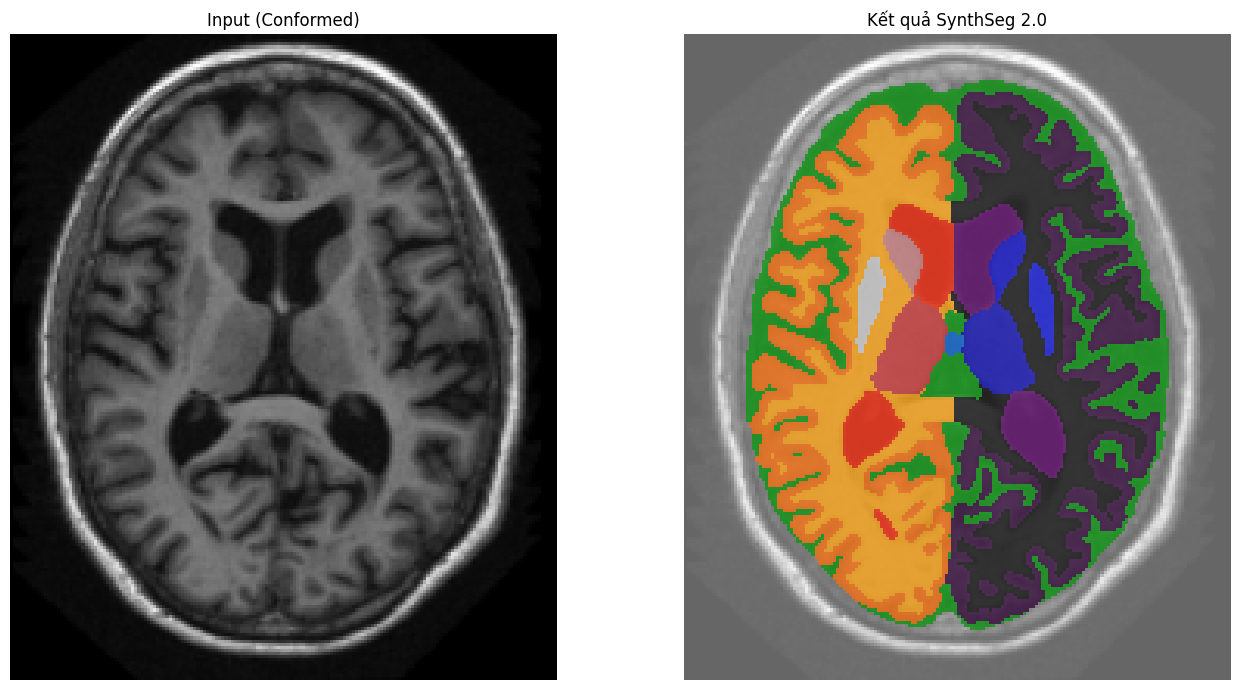

✅ Đã hoàn tất! File kết quả lưu tại: D:\Documents\MRI_Dataset\result_subj_synthseg_2.0.nii.gz


In [ ]:
import os
import nibabel as nib
import surfa as sf
import numpy as np
import matplotlib.pyplot as plt

# ================= 1. CẤU HÌNH ĐƯỜNG DẪN =================
base_dir = r"D:\Documents\MRI_Dataset"
path_to_code_folder = os.path.join(base_dir, "mri_synthseg")
path_to_models = os.path.join(path_to_code_folder, "models")

script_path = os.path.join(path_to_code_folder, "mri_synthseg.py")
model_path = os.path.join(path_to_models, "synthseg_2.0.h5")

os.environ['FREESURFER_HOME'] = path_to_code_folder

input_img_path = r"D:\Documents\MRI_Dataset\oasis_cross-sectional_disc1\disc1\OAS1_0001_MR1\PROCESSED\MPRAGE\T88_111\OAS1_0001_MR1_mpr_n4_anon_111_t88_gfc.img"

# Các file trung gian và kết quả
temp_nifti_raw = os.path.join(base_dir, "temp_subj_raw.nii.gz")
temp_nifti_fixed = os.path.join(base_dir, "input_subj_conformed.nii.gz")
output_seg = os.path.join(base_dir, "result_subj_synthseg_2.0.nii.gz")

# ================= 2. QUY TRÌNH TIỀN XỬ LÝ =================
print("⏳ Đang chuẩn bị dữ liệu đầu vào cho SynthSeg 2.0...")

if os.path.exists(input_img_path):
    try:
        # BƯỚC A: Chuyển .img sang .nii.gz
        if not os.path.exists(temp_nifti_raw):
            print("   -> Đang convert từ .img sang .nii.gz...")
            img_nib = nib.load(input_img_path)
            nib.save(img_nib, temp_nifti_raw)
        
        # BƯỚC B: Nắn chỉnh ảnh bằng Surfa
        print("   -> Đang Conform (Nắn thẳng ảnh)...")
        vol = sf.load_volume(temp_nifti_raw)
        vol_fixed = vol.conform()
        vol_fixed.save(temp_nifti_fixed)
        print(f"✅ Input đã sẵn sàng tại: {temp_nifti_fixed}")

    except Exception as e:
        print(f"❌ Lỗi tiền xử lý ảnh: {e}")
        exit()
else:
    print(f"❌ Không tìm thấy file Input gốc: {input_img_path}")
    exit()

# ================= 3. CHẠY SYNTHSEG 2.0 (ĐÃ SỬA LỖI) =================
if not os.path.exists(script_path):
    print(f"❌ Lỗi: Không tìm thấy script tại {script_path}")
    exit()
if not os.path.exists(model_path):
    print(f"❌ Lỗi: Không tìm thấy model tại {model_path}")
    exit()

print(f"\n🚀 Đang chạy SynthSeg 2.0 với model: {os.path.basename(model_path)}...")

# SỬA LỖI Ở ĐÂY: Thêm cờ --noaddctab
# --noaddctab: Bỏ qua việc tìm file FreeSurferColorLUT.txt
!python "{script_path}" --i "{temp_nifti_fixed}" --o "{output_seg}" --model "{model_path}" --threads 4 --cpu --noaddctab

# ================= 4. HIỂN THỊ KẾT QUẢ =================
print("\n---------------- KIỂM TRA KẾT QUẢ 2.0 ----------------")
if os.path.exists(output_seg):
    vol_input = nib.load(temp_nifti_fixed).get_fdata()
    vol_seg = nib.load(output_seg).get_fdata()
    
    brain_mask = vol_seg > 0
    if np.any(brain_mask):
        center_z = int(np.mean(np.where(brain_mask)[2]))
    else:
        center_z = vol_input.shape[2] // 2

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    # Input
    axes[0].imshow(np.rot90(vol_input[:, :, center_z]), cmap='gray')
    axes[0].set_title("Input (Conformed)")
    axes[0].axis('off')
    
    # Kết quả 2.0
    masked_seg = np.ma.masked_where(vol_seg == 0, vol_seg)
    axes[1].imshow(np.rot90(vol_input[:, :, center_z]), cmap='gray', alpha=0.6)
    axes[1].imshow(np.rot90(masked_seg[:, :, center_z]), cmap='nipy_spectral', alpha=0.7)
    axes[1].set_title("Kết quả SynthSeg 2.0")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    print(f"✅ Đã hoàn tất! File kết quả lưu tại: {output_seg}")
else:
    print("❌ Script chạy xong nhưng không thấy file kết quả.")

⏳ Đang kiểm tra dữ liệu...
✅ Tìm thấy file Input: D:\Documents\MRI_Dataset\OAS1_0001_MR1_mpr_n4_anon_sbj_111_conform.nii.gz
   -> File này đã là .nii.gz chuẩn, sẽ chạy thẳng vào model.

🚀 Đang chạy SynthSeg 2.0 với model: synthseg_2.0.h5...
D:\Documents\MRI_Dataset\mri_synthseg\models\synthseg_2.0.h5
---------------- KIỂM TRA KẾT QUẢ ----------------

using CPU, hiding all CUDA_VISIBLE_DEVICES
using 4 threads
addctab  False
predicting 1/1

1/1 [==============================] - 132s 132s/step

segmentation  saved in:    D:\Documents\MRI_Dataset\result_subj_conform_synthseg_2.0.nii.gz

#@# mri_synthseg vmpeak  None

If you use this tool in a publication, please cite:
SynthSeg: Segmentation of brain MRI scans of any contrast and resolution without retraining
B. Billot, D.N. Greve, O. Puonti, A. Thielscher, K. Van Leemput, B. Fischl, A.V. Dalca, J.E. Iglesias
Medical Image Analysis, 2023.


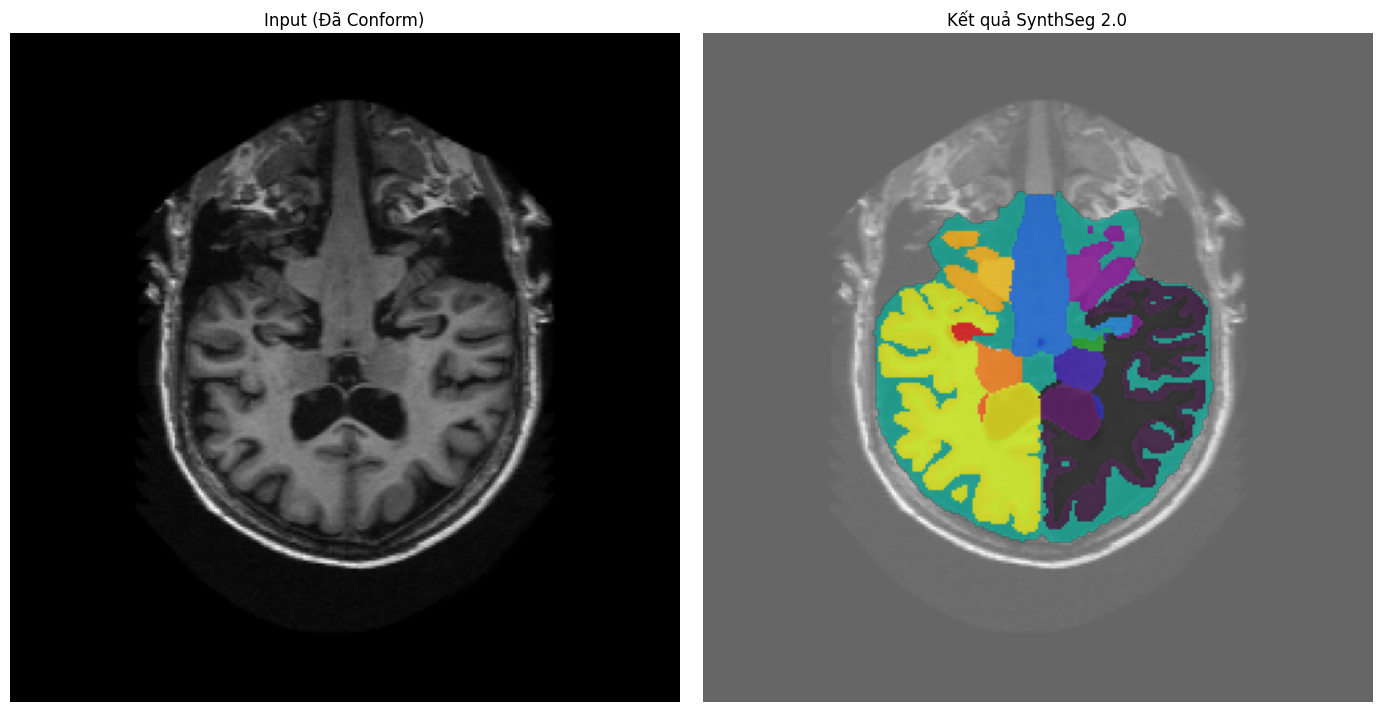

✅ Đã hoàn tất! File kết quả lưu tại: D:\Documents\MRI_Dataset\result_subj_conform_synthseg_2.0.nii.gz


In [2]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ================= 1. CẤU HÌNH ĐƯỜNG DẪN =================
base_dir = r"D:\Documents\MRI_Dataset"
path_to_code_folder = os.path.join(base_dir, "mri_synthseg")
path_to_models = os.path.join(path_to_code_folder, "models")
script_path = os.path.join(path_to_code_folder, "mri_synthseg.py")
model_path = os.path.join(path_to_models, "synthseg_2.0.h5")

os.environ['FREESURFER_HOME'] = path_to_code_folder

# ĐƯỜNG DẪN FILE INPUT CỦA BẠN (Đã là .nii.gz và đã conform)
input_img_path = r"D:\Documents\MRI_Dataset\OAS1_0001_MR1_mpr_n4_anon_sbj_111_conform.nii.gz"

# File kết quả đầu ra
output_seg = os.path.join(base_dir, "result_subj_conform_synthseg_2.0.nii.gz")

# ================= 2. KIỂM TRA ĐẦU VÀO =================
print("⏳ Đang kiểm tra dữ liệu...")

if os.path.exists(input_img_path):
    print(f"✅ Tìm thấy file Input: {input_img_path}")
    print("   -> File này đã là .nii.gz chuẩn, sẽ chạy thẳng vào model.")
else:
    print(f"❌ Lỗi: Không tìm thấy file Input tại: {input_img_path}")
    # Dừng chương trình nếu không thấy file
    raise FileNotFoundError("Kiểm tra lại đường dẫn file input!")

# ================= 3. CHẠY SYNTHSEG 2.0 =================
if not os.path.exists(script_path):
    print(f"❌ Lỗi: Không tìm thấy script tại {script_path}")
    exit()

print(f"\n🚀 Đang chạy SynthSeg 2.0 với model: {os.path.basename(model_path)}...")

# Chạy lệnh Python (Lưu ý: input là input_img_path luôn)
!python "{script_path}" --i "{input_img_path}" --o "{output_seg}" --model "{model_path}" --threads 4 --cpu --noaddctab --crop 192

# ================= 4. HIỂN THỊ KẾT QUẢ =================
print("\n---------------- KIỂM TRA KẾT QUẢ ----------------")
if os.path.exists(output_seg):
    # Load dữ liệu
    vol_input = nib.load(input_img_path).get_fdata()
    vol_seg = nib.load(output_seg).get_fdata()
    
    # Tìm lát cắt trung tâm vùng não
    brain_mask = vol_seg > 0
    if np.any(brain_mask):
        center_z = int(np.mean(np.where(brain_mask)[2]))
    else:
        center_z = vol_input.shape[2] // 2

    # Vẽ hình
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    # Input
    axes[0].imshow(np.rot90(vol_input[:, :, center_z]), cmap='gray')
    axes[0].set_title("Input (Đã Conform)")
    axes[0].axis('off')
    
    # Kết quả
    masked_seg = np.ma.masked_where(vol_seg == 0, vol_seg)
    axes[1].imshow(np.rot90(vol_input[:, :, center_z]), cmap='gray', alpha=0.6)
    axes[1].imshow(np.rot90(masked_seg[:, :, center_z]), cmap='nipy_spectral', alpha=0.7)
    axes[1].set_title("Kết quả SynthSeg 2.0")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    print(f"✅ Đã hoàn tất! File kết quả lưu tại: {output_seg}")
else:
    print("❌ Script chạy xong nhưng không thấy file kết quả. Có thể đã xảy ra lỗi trong quá trình chạy lệnh !python.")

📂 Đang xử lý: 0001_SUBJ
⏳ Đang chuẩn bị dữ liệu...
   -> Đọc và xoay trục (Canonical)...
   -> Đang làm sạch Header và khử nhiễu (NaNs)...
   -> Đang Conform (Surfa)...
✅ Input đã sẵn sàng!

🚀 Đang chạy SynthSeg 2.0...
D:\Documents\MRI_Dataset\mri_synthseg\models\synthseg_2.0.h5
using CPU, hiding all CUDA_VISIBLE_DEVICES
using 4 threads
addctab  False
predicting 1/1

1/1 [==============================] - 258s 258s/step

segmentation  saved in:    D:\Documents\MRI_Dataset\Processed_Results\0001_SUBJ\result_synthseg.nii.gz

#@# mri_synthseg vmpeak  None

If you use this tool in a publication, please cite:
SynthSeg: Segmentation of brain MRI scans of any contrast and resolution without retraining
B. Billot, D.N. Greve, O. Puonti, A. Thielscher, K. Van Leemput, B. Fischl, A.V. Dalca, J.E. Iglesias
Medical Image Analysis, 2023.


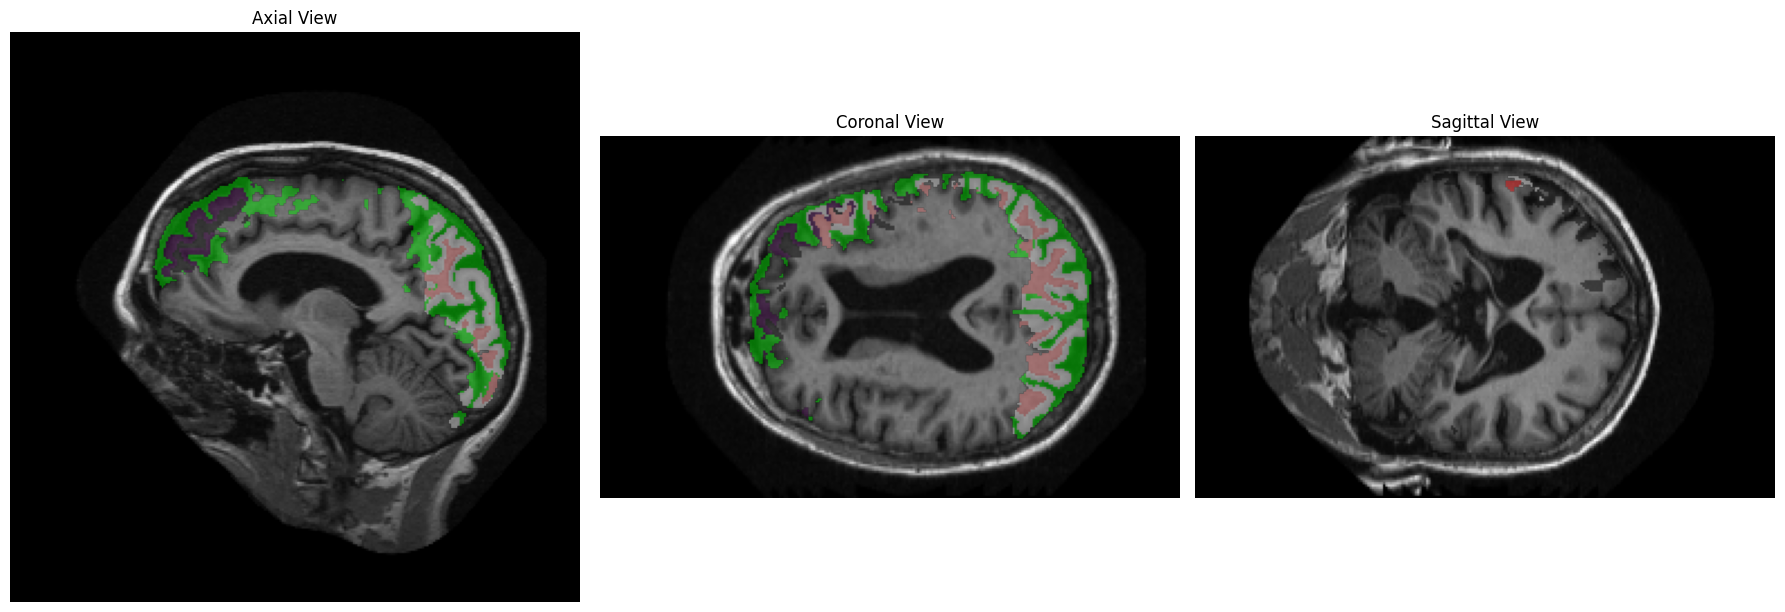

✅ Đã phân vùng thành công! File lưu tại: D:\Documents\MRI_Dataset\Processed_Results\0001_SUBJ\result_synthseg.nii.gz


In [6]:
import os
import nibabel as nib
import surfa as sf
import numpy as np
import matplotlib.pyplot as plt
import sys
import warnings

# Tắt các cảnh báo Deprecation rác để dễ nhìn log
warnings.filterwarnings('ignore')

# ================= 1. CẤU HÌNH ĐƯỜNG DẪN =================
base_dir = r"D:\Documents\MRI_Dataset"
path_to_code_folder = os.path.join(base_dir, "mri_synthseg")
path_to_models = os.path.join(path_to_code_folder, "models")
script_path = os.path.join(path_to_code_folder, "mri_synthseg.py")
model_path = os.path.join(path_to_models, "synthseg_2.0.h5")

os.environ['FREESURFER_HOME'] = path_to_code_folder

# --- INPUT FILE ---
input_img_path = r"D:\Documents\MRI_Dataset\oasis_cross-sectional_disc1\disc1\OAS1_0001_MR1\PROCESSED\MPRAGE\SUBJ_111\OAS1_0001_MR1_mpr_n4_anon_sbj_111.img"

# Tự động tạo folder output
filename = os.path.basename(input_img_path)
try:
    subj_id = filename.split('_')[1]
    img_type = "SUBJ" if "sbj" in filename else "T88"
    folder_name = f"{subj_id}_{img_type}"
except:
    folder_name = "Unknown_Result"

current_output_dir = os.path.join(base_dir, "Processed_Results", folder_name)
os.makedirs(current_output_dir, exist_ok=True)

print(f"📂 Đang xử lý: {folder_name}")

temp_nifti_raw = os.path.join(current_output_dir, "temp_raw.nii.gz")
temp_nifti_fixed = os.path.join(current_output_dir, "input_conformed.nii.gz")
output_seg = os.path.join(current_output_dir, "result_synthseg.nii.gz")

# ================= 2. QUY TRÌNH TIỀN XỬ LÝ (LÀM SẠCH SÂU) =================
print("⏳ Đang chuẩn bị dữ liệu...")

if os.path.exists(input_img_path):
    try:
        print("   -> Đọc và xoay trục (Canonical)...")
        img = nib.load(input_img_path)
        img_canon = nib.as_closest_canonical(img)
        
        # --- FIX LỖI CRASH Ở ĐÂY ---
        print("   -> Đang làm sạch Header và khử nhiễu (NaNs)...")
        
        # 1. Rút dữ liệu ra và ép kiểu về float32 an toàn cho AI
        data = np.asarray(img_canon.dataobj, dtype=np.float32)
        
        # 2. Khử toàn bộ giá trị NaN/Inf (Kẻ thù làm crash SynthSeg)
        data = np.nan_to_num(data) 
        
        # 3. Tạo một Affine chuẩn mực để tránh lỗi mảng Numpy
        affine = np.array(img_canon.affine, dtype=np.float64)
        
        # 4. Đúc NIfTI mới tinh, bỏ lại Header Analyze rác ở phía sau
        clean_nii = nib.Nifti1Image(data, affine)
        clean_nii.header.set_qform(affine, code=1)
        clean_nii.header.set_sform(affine, code=1)
        
        nib.save(clean_nii, temp_nifti_raw)
        
        print("   -> Đang Conform (Surfa)...")
        vol = sf.load_volume(temp_nifti_raw)
        vol_fixed = vol.conform()
        vol_fixed.save(temp_nifti_fixed)
        print(f"✅ Input đã sẵn sàng!")

    except Exception as e:
        print(f"❌ Lỗi xử lý ảnh: {e}")
        sys.exit()
else:
    print(f"❌ Không tìm thấy file Input: {input_img_path}")
    sys.exit()

# ================= 3. CHẠY SYNTHSEG 2.0 =================
if not os.path.exists(script_path):
    print(f"❌ Lỗi script.")
    sys.exit()

# Xóa file cũ nếu có để tránh nhầm lẫn
if os.path.exists(output_seg):
    os.remove(output_seg)

print(f"\n🚀 Đang chạy SynthSeg 2.0...")
!python "{script_path}" --i "{temp_nifti_fixed}" --o "{output_seg}" --model "{model_path}" --threads 4 --cpu --noaddctab

# ================= 4. HIỂN THỊ KẾT QUẢ =================
if os.path.exists(output_seg):
    vol_input = nib.load(temp_nifti_fixed).get_fdata()
    vol_seg = nib.load(output_seg).get_fdata()
    
    brain_mask = vol_seg > 0
    if np.any(brain_mask):
        center_coords = np.mean(np.where(brain_mask), axis=1).astype(int)
        z, y, x = center_coords[2], center_coords[1], center_coords[0]
    else:
        z = vol_input.shape[2] // 2
        y = vol_input.shape[1] // 2
        x = vol_input.shape[0] // 2

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Hiển thị 3 mặt phẳng để check
    axes[0].imshow(np.rot90(vol_input[:, :, z]), cmap='gray')
    axes[0].imshow(np.rot90(np.ma.masked_where(vol_seg[:,:,z]==0, vol_seg[:,:,z])), cmap='nipy_spectral', alpha=0.5)
    axes[0].set_title("Axial View")
    axes[0].axis('off')

    axes[1].imshow(np.rot90(vol_input[:, y, :]), cmap='gray')
    axes[1].imshow(np.rot90(np.ma.masked_where(vol_seg[:,y,:]==0, vol_seg[:,y,:])), cmap='nipy_spectral', alpha=0.5)
    axes[1].set_title("Coronal View")
    axes[1].axis('off')
    
    axes[2].imshow(np.rot90(vol_input[x, :, :]), cmap='gray')
    axes[2].imshow(np.rot90(np.ma.masked_where(vol_seg[x,:,:]==0, vol_seg[x,:,:])), cmap='nipy_spectral', alpha=0.5)
    axes[2].set_title("Sagittal View")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    print(f"✅ Đã phân vùng thành công! File lưu tại: {output_seg}")
else:
    print("❌ Script SynthSeg chạy xong nhưng vẫn không có output.")

In [2]:
import pandas as pd

# ================= 5. TÍNH TOÁN THỂ TÍCH (VOLUMETRY) =================
print("\n📊 ĐANG TÍNH TOÁN THỂ TÍCH CÁC VÙNG NÃO...")

# 1. Bảng tra cứu nhãn (FreeSurfer ColorLUT chuẩn)
# SynthSeg dùng chung bảng mã này với FreeSurfer
FS_LUT = {
    2: "Left-Cerebral-White-Matter",
    3: "Left-Cerebral-Cortex",
    4: "Left-Lateral-Ventricle",
    5: "Left-Inf-Lat-Vent",
    7: "Left-Cerebellum-White-Matter",
    8: "Left-Cerebellum-Cortex",
    10: "Left-Thalamus",
    11: "Left-Caudate",
    12: "Left-Putamen",
    13: "Left-Pallidum",
    14: "3rd-Ventricle",
    15: "4th-Ventricle",
    16: "Brain-Stem",
    17: "Left-Hippocampus",
    18: "Left-Amygdala",
    24: "CSF",
    26: "Left-Accumbens-area",
    28: "Left-VentralDC",
    41: "Right-Cerebral-White-Matter",
    42: "Right-Cerebral-Cortex",
    43: "Right-Lateral-Ventricle",
    44: "Right-Inf-Lat-Vent",
    46: "Right-Cerebellum-White-Matter",
    47: "Right-Cerebellum-Cortex",
    49: "Right-Thalamus",
    50: "Right-Caudate",
    51: "Right-Putamen",
    52: "Right-Pallidum",
    53: "Right-Hippocampus",
    54: "Right-Amygdala",
    58: "Right-Accumbens-area",
    60: "Right-VentralDC"
    # Bạn có thể thêm các mã khác nếu cần, nhưng đây là các vùng chính SynthSeg tách được
}

# 2. Đường dẫn file stats đầu ra
output_stats_csv = os.path.join(base_dir, "aseg+DST.csv")   # Dạng bảng dễ đọc bằng Excel
output_stats_txt = os.path.join(base_dir, "aseg+DST.stats") # Dạng text giống FreeSurfer

try:
    # Load lại file kết quả segmentation
    if not os.path.exists(output_seg):
        raise FileNotFoundError(f"Không tìm thấy file kết quả: {output_seg}")

    img_seg = nib.load(output_seg)
    data_seg = img_seg.get_fdata().astype(int)
    
    # Lấy kích thước voxel (thường là 1x1x1 mm3 sau khi conform)
    # np.prod nhân 3 chiều (x*y*z) để ra thể tích 1 voxel
    voxel_vol_mm3 = np.prod(img_seg.header.get_zooms())
    
    print(f" -> Kích thước 1 voxel: {voxel_vol_mm3:.4f} mm3")

    # 3. Tính toán
    stats_list = []
    unique_labels = np.unique(data_seg)
    
    total_segmented_vol = 0

    for label_id in unique_labels:
        if label_id == 0: continue # Bỏ qua nền (background)
        
        # Đếm số voxel của nhãn này
        count = np.sum(data_seg == label_id)
        volume_mm3 = count * voxel_vol_mm3
        total_segmented_vol += volume_mm3
        
        # Lấy tên vùng từ LUT, nếu không có thì để Unknown
        struct_name = FS_LUT.get(label_id, f"Unknown-Label-{label_id}")
        
        stats_list.append({
            "SegId": label_id,
            "StructName": struct_name,
            "Volume_mm3": round(volume_mm3, 4),
            "NVoxels": count
        })

    # Tạo DataFrame và sắp xếp theo ID
    df = pd.DataFrame(stats_list)
    df = df.sort_values(by="SegId")

    # 4. Xuất file CSV (Dễ dùng cho Excel/Pandas)
    df.to_csv(output_stats_csv, index=False)
    print(f"✅ Đã lưu file CSV tại: {output_stats_csv}")

    # 5. Xuất file .stats (Mô phỏng format FreeSurfer)
    with open(output_stats_txt, 'w') as f:
        f.write(f"# Stats generated from SynthSeg 2.0 result\n")
        f.write(f"# Source file: {output_seg}\n")
        f.write(f"# Total Segmented Volume: {total_segmented_vol:.2f} mm3\n")
        f.write(f"{'SegId':<10} {'StructName':<35} {'Volume_mm3':<15} {'NVoxels':<10}\n")
        f.write("-" * 70 + "\n")
        for index, row in df.iterrows():
            f.write(f"{row['SegId']:<10} {row['StructName']:<35} {row['Volume_mm3']:<15} {row['NVoxels']:<10}\n")
    
    print(f"✅ Đã lưu file Stats tại: {output_stats_txt}")

    # 6. In nhanh kết quả quan trọng (Hippocampus & Ventricles) để kiểm tra
    print("\n--- KẾT QUẢ QUAN TRỌNG (DỰ ĐOÁN ALZHEIMER) ---")
    targets = ["Hippocampus", "Lateral-Ventricle"]
    for index, row in df.iterrows():
        if any(t in row['StructName'] for t in targets):
            print(f" - {row['StructName']}: {row['Volume_mm3']} mm3")

except Exception as e:
    print(f"❌ Lỗi tính toán stats: {e}")


📊 ĐANG TÍNH TOÁN THỂ TÍCH CÁC VÙNG NÃO...
 -> Kích thước 1 voxel: 1.0000 mm3
✅ Đã lưu file CSV tại: D:\Documents\MRI_Dataset\aseg+DST.csv
✅ Đã lưu file Stats tại: D:\Documents\MRI_Dataset\aseg+DST.stats

--- KẾT QUẢ QUAN TRỌNG (DỰ ĐOÁN ALZHEIMER) ---
 - Left-Lateral-Ventricle: 39005.0 mm3
 - Left-Hippocampus: 5169.0 mm3
 - Right-Lateral-Ventricle: 32677.0 mm3
 - Right-Hippocampus: 5358.0 mm3


In [2]:
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

# ================= CẤU HÌNH CHO PHẦN TIẾP THEO =================
# Lấy lại đường dẫn từ Cell cũ
base_dir = r"D:\Documents\MRI_Dataset"
conformed_input = os.path.join(base_dir, "input_t88_conformed.nii.gz") # File đã nắn từ Cell 2
synthseg_output = os.path.join(base_dir, "result_t88_synthseg_2.0.nii.gz") # Kết quả từ Cell 3

# Đường dẫn file output mới cho HD-BET
hdbet_output = os.path.join(base_dir, "result_hdbet_stripped.nii.gz")
synthseg_stripped = os.path.join(base_dir, "result_synthseg_stripped.nii.gz")

In [3]:
print("⏳ ĐANG CẮT SỌ DỰA TRÊN KẾT QUẢ SYNTHSEG...")

try:
    if os.path.exists(conformed_input) and os.path.exists(synthseg_output):
        # Load ảnh gốc (Conformed) và ảnh Segmentation
        img_input = nib.load(conformed_input)
        img_seg = nib.load(synthseg_output)
        
        data_input = img_input.get_fdata()
        data_seg = img_seg.get_fdata()
        
        # Tạo mask: Bất kỳ chỗ nào SynthSeg tô màu (label > 0) thì giữ lại
        brain_mask = data_seg > 0
        
        # Áp mask lên ảnh gốc
        data_stripped = data_input.copy()
        data_stripped[~brain_mask] = 0 # Xóa hết những chỗ không phải não
        
        # Lưu file
        new_img = nib.Nifti1Image(data_stripped, img_input.affine, img_input.header)
        nib.save(new_img, synthseg_stripped)
        
        print(f"✅ Đã tạo ảnh sạch sọ từ SynthSeg Mask: {synthseg_stripped}")
    else:
        print("❌ Thiếu file input hoặc file segmentation.")
except Exception as e:
    print(f"❌ Lỗi xử lý: {e}")

⏳ ĐANG CẮT SỌ DỰA TRÊN KẾT QUẢ SYNTHSEG...
✅ Đã tạo ảnh sạch sọ từ SynthSeg Mask: D:\Documents\MRI_Dataset\result_synthseg_stripped.nii.gz


---------------- SO SÁNH KẾT QUẢ ----------------


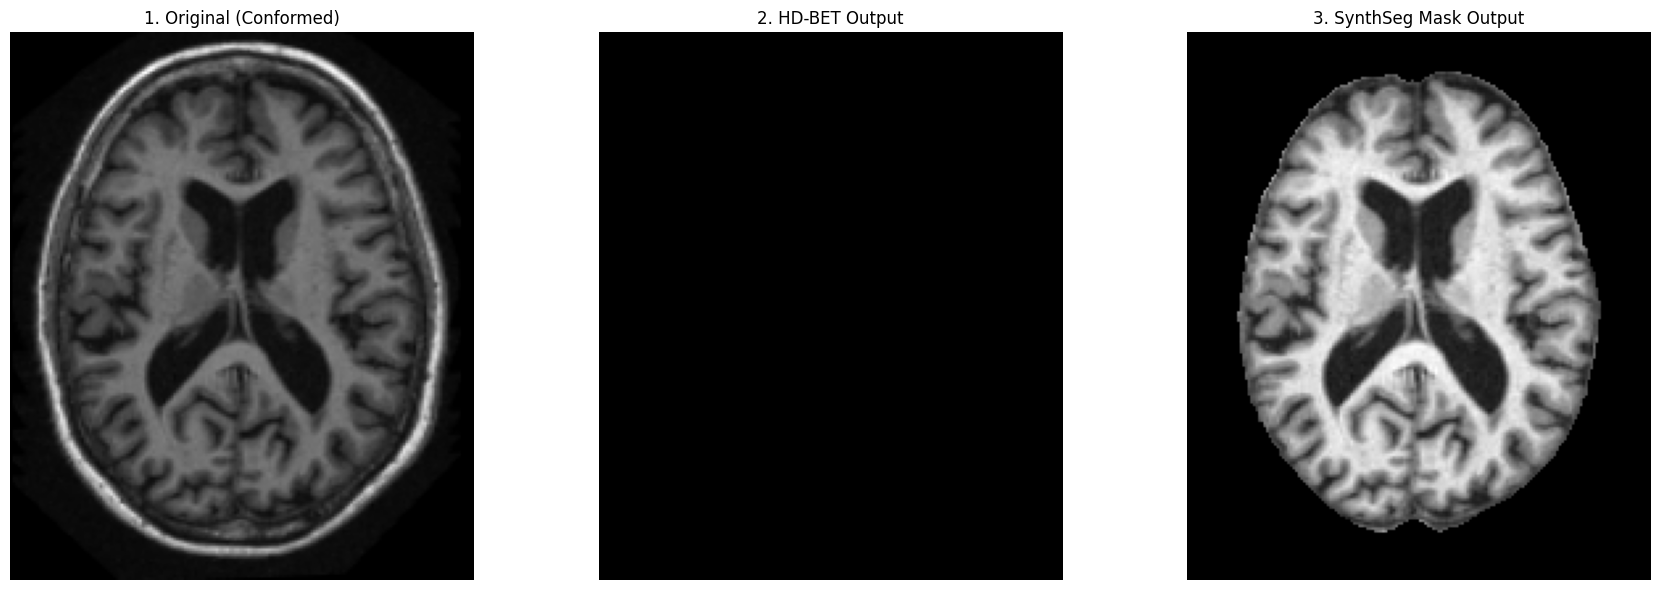

In [ ]:
print("---------------- SO SÁNH KẾT QUẢ ----------------")

# Load dữ liệu để hiển thị
vol_orig = nib.load(conformed_input).get_fdata()
vol_hdbet = nib.load(hdbet_output).get_fdata() if os.path.exists(hdbet_output) else np.zeros_like(vol_orig)
vol_synth = nib.load(synthseg_stripped).get_fdata() if os.path.exists(synthseg_stripped) else np.zeros_like(vol_orig)

# Tìm lát cắt giữa
center_z = vol_orig.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Ảnh gốc (Conformed)
axes[0].imshow(np.rot90(vol_orig[:, :, center_z]), cmap='gray')
axes[0].set_title("1. Original (Conformed)")
axes[0].axis('off')

# 3. Kết quả cắt bằng SynthSeg Mask
axes[2].imshow(np.rot90(vol_synth[:, :, center_z]), cmap='gray')
axes[2].set_title("2. SynthSeg Mask Output")
axes[2].axis('off')

plt.tight_layout()
plt.show()